# Notebook 5: Contractor Clustering

## Overview

The final stage of the analysis pipeline clusters federal contractors into
distinct economic profiles using three features derived from the preceding
notebooks. Clustering is performed at the **corporate family level**: 
contractor names are grouped by their first two words to approximate parent
company identity, aggregating the activity of registered subsidiaries under
a common label.

## Feature Vector

| Feature | Source | Description |
|---|---|---|
| `total_obligations` | `contracts_with_hits.csv` | Sum of all FY2025 contract dollars awarded to the corporate family |
| `unique_naics_count` | `contracts_with_hits.csv` | Number of distinct service categories contracted — measures diversity |
| `authority_score` | `corporate_family_authority_scores.csv` | Aggregated HITS authority score — measures structural network influence |

## Methods

Two clustering algorithms are applied and compared:

- **K-Means**: Partitions contractors into k clusters by minimizing intra-cluster
  variance. Assumes roughly spherical, equal-sized clusters. Produces hard
  (deterministic) assignments.
- **GMM (Gaussian Mixture Model)**: Models the data as a mixture of k Gaussian
  distributions. Allows elliptical cluster shapes and produces soft probabilistic
  assignments. More appropriate when cluster boundaries are gradual rather than sharp.

The optimal number of clusters is selected using the elbow method (inertia)
and silhouette score analysis before fitting final models.

**Input:** `contracts_with_hits.csv`, `corporate_family_authority_scores.csv`  
**Output:** `contractor_clusters.csv`

## Setup & Imports

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

## Build Corporate Family Feature Matrix

Contractor names are grouped by their first two words to approximate corporate
parent identity. Total obligations and unique NAICS count are aggregated by
this grouping from `contracts_with_hits.csv`. Authority scores are merged in
from `corporate_family_authority_scores.csv`, which was computed in Notebook 3.

Corporate families with no matching authority score (contractors that appear
in the contracts data but not in the HITS output) receive a score of 0.

In [14]:
df = pd.read_csv('contracts_with_hits.csv', dtype={'naics_code': str})

def first_two_words(name):
    tokens = str(name).split()
    return ' '.join(tokens[:2]) if len(tokens) >= 2 else name

df['corporate_family'] = df['recipient_name'].apply(first_two_words)

# Aggregate all three features at corporate family level
features = df.groupby('corporate_family').agg(
    total_obligations=('total_obligated_amount', 'sum'),
    unique_naics_count=('naics_code', 'nunique'),
).reset_index()

# Merge in authority scores
auth_scores = pd.read_csv('corporate_family_authority_scores.csv')
features = features.merge(auth_scores, on='corporate_family', how='left')
features['authority_score'] = features['authority_score'].fillna(0)

print(f"Corporate families: {len(features)}")
print(f"\nFeature summary:")
print(features[['total_obligations', 'unique_naics_count', 'authority_score']].describe())

Corporate families: 23038

Feature summary:
       total_obligations  unique_naics_count  authority_score
count       2.303800e+04        23038.000000     2.303800e+04
mean        1.244089e+08            1.611815     4.340655e-05
std         4.022950e+09            2.116495     1.864737e-03
min         0.000000e+00            1.000000    -6.383822e-30
25%         2.566093e+05            1.000000     5.353693e-12
50%         1.441859e+06            1.000000     7.970255e-09
75%         7.883890e+06            2.000000     1.100839e-06
max         4.971325e+11          174.000000     2.340612e-01


## Data Quality Checks

Two issues are addressed before scaling:

1. **Negative authority scores**: A floating point result of the HITS
   iterative computation produces values like `-1.6e-30` which are
   mathematically zero but technically negative. These are floored to 0.

2. **Zero total obligations**: 241 corporate families have zero summed
   obligations, indicating data entry anomalies or fully de-obligated
   contracts. These are dropped as they carry no meaningful economic profile
   to cluster on.

In [15]:
# Floor negative authority scores (floating point artifact from HITS)
features['authority_score'] = features['authority_score'].clip(lower=0)

# Drop corporate families with zero total obligations
before = len(features)
features = features[features['total_obligations'] > 0]
print(f"\nDropped {before - len(features)} families with zero obligations")
print(f"Corporate families remaining: {len(features)}")


Dropped 241 families with zero obligations
Corporate families remaining: 22797


## Feature Scaling

Features are standardized using `StandardScaler` (zero mean, unit variance)
before clustering. This ensures no single feature dominates distance
calculations due to differences in units or magnitude.

Note: Log transformation is applied in Section 2 after initial clustering
revealed outlier dominance issues with raw scaled features.

In [16]:
X = features[['total_obligations', 'unique_naics_count', 'authority_score']].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features scaled. Shape:", X_scaled.shape)

Features scaled. Shape: (22797, 3)


## Section 1: Selecting Optimal k

The elbow method plots inertia (within-cluster sum of squares) against k.
The silhouette score measures how well-separated clusters are. Values closer
to 1.0 indicate tight, well-defined clusters. Both are computed for k=2
through k=9 to guide selection of the optimal number of clusters.

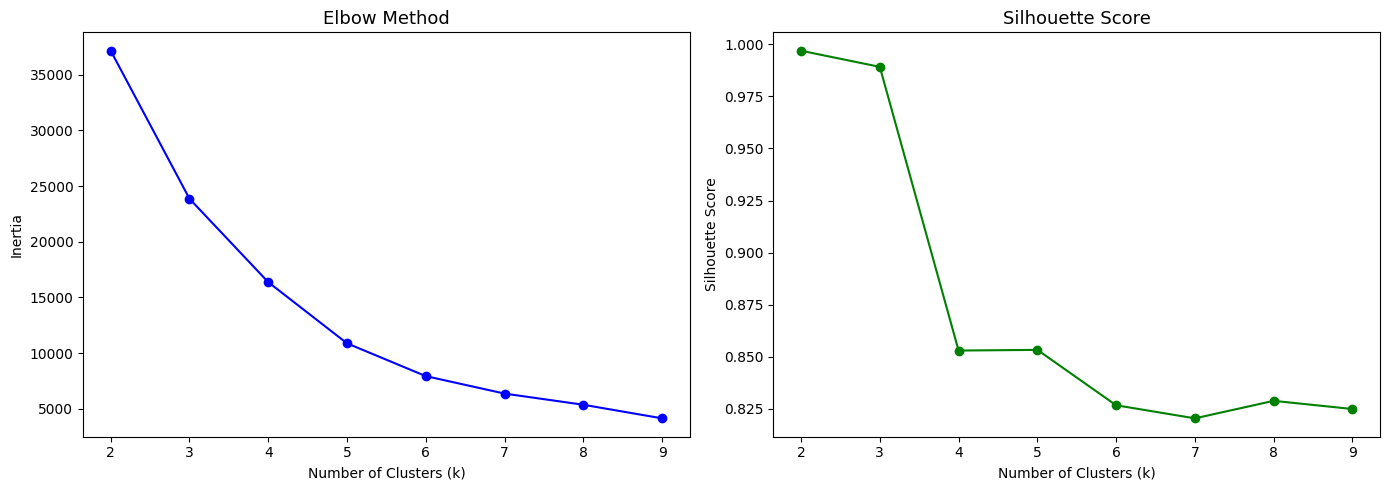

Silhouette scores:
  k=2: 0.9969
  k=3: 0.9892
  k=4: 0.8530
  k=5: 0.8533
  k=6: 0.8268
  k=7: 0.8205
  k=8: 0.8289
  k=9: 0.8250


In [17]:
k_range = range(2, 10)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, 'bo-')
axes[0].set_title('Elbow Method', fontsize=13)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, silhouettes, 'go-')
axes[1].set_title('Silhouette Score', fontsize=13)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.savefig('clustering_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

print("Silhouette scores:")
for k, s in zip(k_range, silhouettes):
    print(f"  k={k}: {s:.4f}")

## Section 1 Results: Initial Clustering (Raw Scaled Features)

Based on the elbow and silhouette analysis, k=3 is selected. Despite k=2
having a marginally higher silhouette score (0.997 vs 0.989), k=3 is
preferred for analytical interpretability. Three clusters map naturally
to the hypothesized contractor profiles (dominant primes, mid-tier
specialists, small niche contractors) whereas k=2 would produce only a
binary split.

In [18]:
K = 3

# K-Means
km = KMeans(n_clusters=K, random_state=42, n_init=10)
km_labels = km.fit_predict(X_scaled)
features['kmeans_cluster'] = km_labels

# GMM
gmm = GaussianMixture(n_components=K, random_state=42, n_init=5)
gmm.fit(X_scaled)
gmm_labels = gmm.predict(X_scaled)
gmm_probs = gmm.predict_proba(X_scaled)
features['gmm_cluster'] = gmm_labels

# Agreement between methods
agreement = (km_labels == gmm_labels).mean()
print(f"K-Means vs GMM label agreement: {agreement*100:.1f}%")
print(f"\nK-Means cluster sizes:")
print(features['kmeans_cluster'].value_counts().sort_index())
print(f"\nGMM cluster sizes:")
print(features['gmm_cluster'].value_counts().sort_index())

K-Means vs GMM label agreement: 89.3%

K-Means cluster sizes:
kmeans_cluster
0    22788
1        1
2        8
Name: count, dtype: int64

GMM cluster sizes:
gmm_cluster
0    20344
1        1
2     2452
Name: count, dtype: int64


## Observation: Cluster Imbalance Due to Outlier Dominance

Initial clustering with raw scaled features produces severely imbalanced clusters:
- K-Means: 22,788 / 1 / 8
- GMM: 20,344 / 1 / 2,452

This is a known consequence of extreme outliers in the feature space. A small number
of dominant defense contractors (e.g. Lockheed Martin, Boeing, Raytheon) have
authority scores and total obligations orders of magnitude larger than the rest of
the dataset. Under Euclidean distance, these outliers dominate the cluster geometry
and collapse the majority of contractors into a single undifferentiated mass.

**Solution:** Log-transform `total_obligations` and `authority_score` prior to
scaling. Both features are heavily right-skewed. The log transformation compresses
the extreme values while preserving the relative ordering of contractors, allowing
K-Means and GMM to find meaningful structure across the full distribution.

`unique_naics_count` is left untransformed as it is already relatively compact
(range 1–174) and approximately interpretable on its natural scale.

## Section 2: Clustering with Log-Transformed Features

In [19]:
# Log transform skewed features before scaling
# log1p used to safely handle any zero values
features['log_obligations'] = np.log1p(features['total_obligations'])
features['log_authority'] = np.log1p(features['authority_score'])

X = features[['log_obligations', 'unique_naics_count', 'log_authority']].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features after log transform and scaling:")
print(pd.DataFrame(X_scaled, 
      columns=['log_obligations', 'unique_naics_count', 'log_authority'])
      .describe().round(3))

Features after log transform and scaling:
       log_obligations  unique_naics_count  log_authority
count        22797.000           22797.000      22797.000
mean             0.000              -0.000          0.000
std              1.000               1.000          1.000
min             -5.707              -0.291         -0.024
25%             -0.694              -0.291         -0.024
50%             -0.013              -0.291         -0.024
75%              0.664               0.180         -0.024
max              5.084              81.057        121.703


### Selecting k with Log-Transformed Features

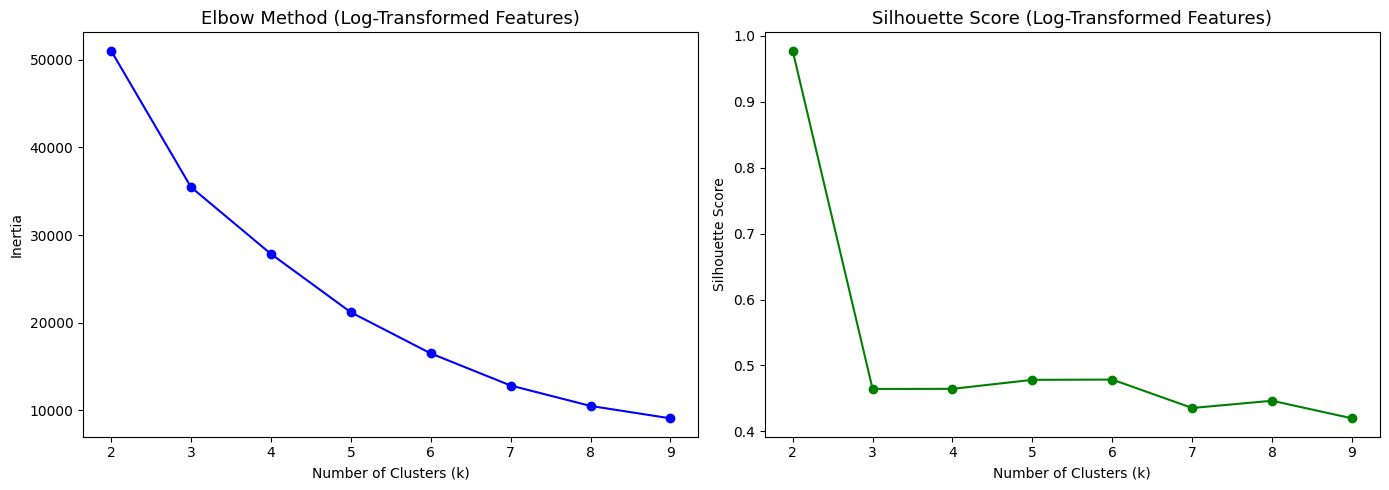

Silhouette scores:
  k=2: 0.9776
  k=3: 0.4644
  k=4: 0.4645
  k=5: 0.4782
  k=6: 0.4785
  k=7: 0.4355
  k=8: 0.4464
  k=9: 0.4197


In [20]:
k_range = range(2, 10)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, 'bo-')
axes[0].set_title('Elbow Method (Log-Transformed Features)', fontsize=13)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, silhouettes, 'go-')
axes[1].set_title('Silhouette Score (Log-Transformed Features)', fontsize=13)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.savefig('clustering_k_selection_log.png', dpi=150, bbox_inches='tight')
plt.show()

print("Silhouette scores:")
for k, s in zip(k_range, silhouettes):
    print(f"  k={k}: {s:.4f}")

### Fit K-Means and GMM (k=3)

Both models are fit on the log-transformed scaled features. K-Means and GMM
label agreement is reported as a measure of cluster stability: high agreement
suggests robust, well-defined clusters while low agreement indicates gradual
or ambiguous boundaries.

In [21]:
K = 3

km = KMeans(n_clusters=K, random_state=42, n_init=10)
km_labels = km.fit_predict(X_scaled)
features['kmeans_cluster'] = km_labels

gmm = GaussianMixture(n_components=K, random_state=42, n_init=5)
gmm.fit(X_scaled)
gmm_labels = gmm.predict(X_scaled)
features['gmm_cluster'] = gmm_labels

agreement = (km_labels == gmm_labels).mean()
print(f"K-Means vs GMM label agreement: {agreement*100:.1f}%")
print(f"\nK-Means cluster sizes:")
print(features['kmeans_cluster'].value_counts().sort_index())
print(f"\nGMM cluster sizes:")
print(features['gmm_cluster'].value_counts().sort_index())

K-Means vs GMM label agreement: 73.2%

K-Means cluster sizes:
kmeans_cluster
0     9641
1    13150
2        6
Name: count, dtype: int64

GMM cluster sizes:
gmm_cluster
0     3934
1    18360
2      503
Name: count, dtype: int64


### Cluster Profiles

Raw (untransformed) feature means and medians are examined per cluster
alongside the top contractors by obligations within each cluster. This
reveals the economic identity of each group and informs the interpretable
labels assigned in the next cell.

In [22]:
# Analyze cluster profiles using original (untransformed) features
# for interpretability
profile_cols = ['total_obligations', 'unique_naics_count', 'authority_score']

print("=== K-Means Cluster Profiles ===")
km_profiles = features.groupby('kmeans_cluster')[profile_cols].agg(['mean', 'median'])
print(km_profiles.to_string())

print("\n=== GMM Cluster Profiles ===")
gmm_profiles = features.groupby('gmm_cluster')[profile_cols].agg(['mean', 'median'])
print(gmm_profiles.to_string())

print("\n=== K-Means: Top 5 contractors per cluster by obligations ===")
for cluster in sorted(features['kmeans_cluster'].unique()):
    top = (features[features['kmeans_cluster'] == cluster]
           .nlargest(5, 'total_obligations')[['corporate_family', 
           'total_obligations', 'unique_naics_count', 'authority_score']])
    print(f"\nCluster {cluster}:")
    print(top.to_string(index=False))

=== K-Means Cluster Profiles ===
               total_obligations               unique_naics_count        authority_score              
                            mean        median               mean median            mean        median
kmeans_cluster                                                                                        
0                   1.873285e+08  1.091509e+07           2.254953    1.0    5.178572e-05  1.825845e-06
1                   6.356360e+05  3.650491e+05           1.122814    1.0    1.535213e-07  3.853971e-11
2                   1.752901e+11  1.309070e+11          63.666667   52.0    8.311918e-02  6.736850e-02

=== GMM Cluster Profiles ===
            total_obligations               unique_naics_count        authority_score              
                         mean        median               mean median            mean        median
gmm_cluster                                                                                        
0                4.

### Cluster Labeling & Visualization

Based on the profile analysis, three interpretable labels are assigned:
- **Defense Prime**: cluster with highest obligations, NAICS diversity, and authority score (Major Defense Companies)
- **Mid-Tier Specialist**: moderate obligations, narrow service portfolio
- **Small Niche Contractor**: near-zero obligations and authority, single NAICS code

A PCA projection reduces the 3D feature space to 2 dimensions for visual
inspection of cluster separation. A log-scale bar chart shows mean feature
values per cluster, allowing all three features to be compared across
clusters despite their differing magnitudes.

In [23]:
km_label_map = {
    2: 'Defense Prime',
    0: 'Mid-Tier Specialist',
    1: 'Small Niche Contractor'
}
gmm_label_map = {
    2: 'Large Diversified',
    0: 'Mid-Tier',
    1: 'Small Niche'
}


features['kmeans_label'] = features['kmeans_cluster'].map(km_label_map)
features['gmm_label'] = features['gmm_cluster'].map(gmm_label_map)

print("K-Means label distribution:")
print(features['kmeans_label'].value_counts())

K-Means label distribution:
kmeans_label
Small Niche Contractor    13150
Mid-Tier Specialist        9641
Defense Prime                 6
Name: count, dtype: int64


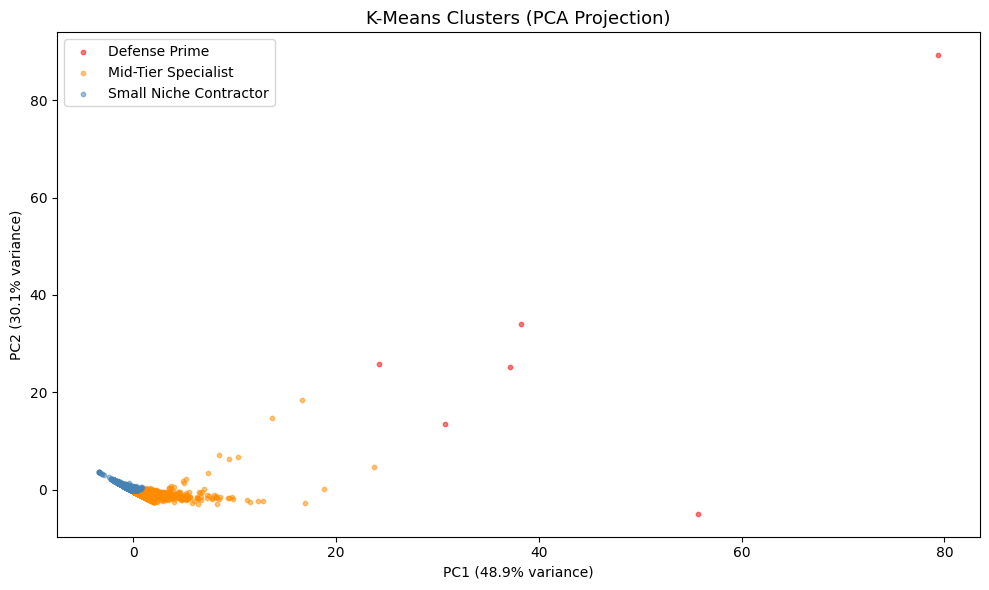

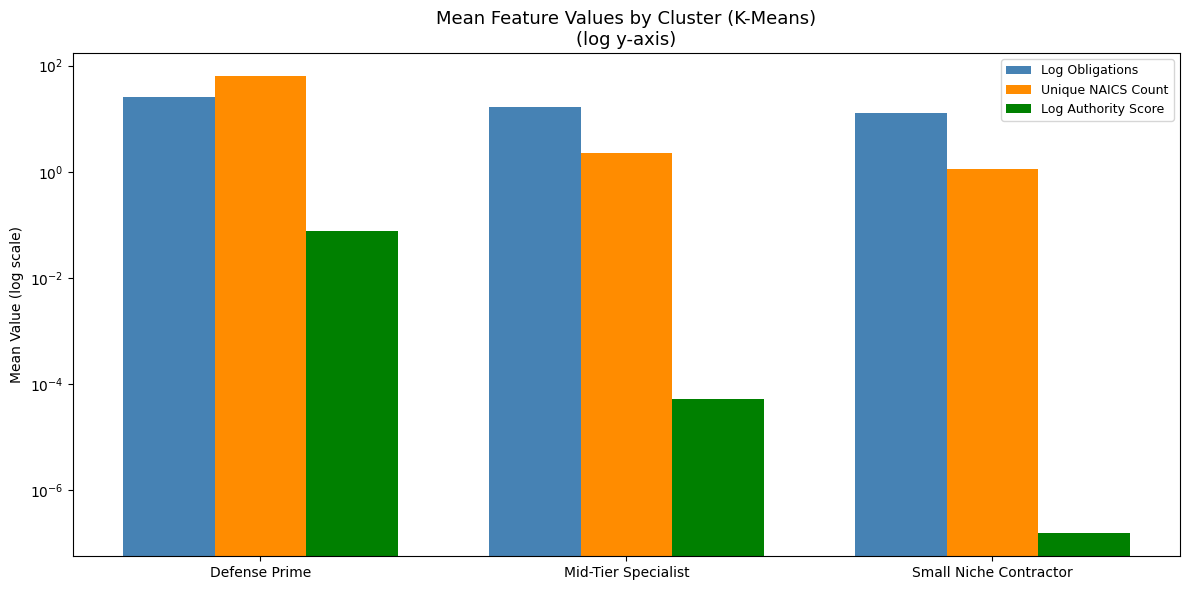

Saved clustering_pca.png and clustering_results.png


In [24]:
# PCA projection
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

colors = {'Defense Prime': 'red',
          'Mid-Tier Specialist': 'darkorange',
          'Small Niche Contractor': 'steelblue'}

fig, ax_pca = plt.subplots(figsize=(10, 6))
for label, color in colors.items():
    mask = features['kmeans_label'] == label
    ax_pca.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=color, label=label, alpha=0.5, s=10)
ax_pca.set_title('K-Means Clusters (PCA Projection)', fontsize=13)
ax_pca.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax_pca.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax_pca.legend()
plt.tight_layout()
plt.savefig('clustering_pca.png', dpi=150, bbox_inches='tight')
plt.show()

# Cluster profile bar chart
cluster_means = features.groupby('kmeans_label').agg(
    log_obligations=('log_obligations', 'mean'),
    unique_naics_count=('unique_naics_count', 'mean'),
    log_authority=('log_authority', 'mean')
).reindex(['Defense Prime', 'Mid-Tier Specialist', 'Small Niche Contractor'])

x = np.arange(len(cluster_means))
width = 0.25

fig2, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, cluster_means['log_obligations'],
       width, label='Log Obligations', color='steelblue')
ax.bar(x, cluster_means['unique_naics_count'],
       width, label='Unique NAICS Count', color='darkorange')
ax.bar(x + width, cluster_means['log_authority'],
       width, label='Log Authority Score', color='green')

ax.set_yscale('log')
ax.set_title('Mean Feature Values by Cluster (K-Means)\n(log y-axis)', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(cluster_means.index, fontsize=10)
ax.legend(fontsize=9)
ax.set_ylabel('Mean Value (log scale)')

plt.tight_layout()
plt.savefig('clustering_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved clustering_pca.png and clustering_results.png")

### Cluster Summary

In [25]:
print("=== Final Cluster Summary (K-Means) ===\n")
summary = features.groupby('kmeans_label').agg(
    count=('corporate_family', 'count'),
    median_obligations=('total_obligations', 'median'),
    mean_naics=('unique_naics_count', 'mean'),
    mean_authority=('authority_score', 'mean')
).reindex(['Defense Prime', 'Mid-Tier Specialist', 'Small Niche Contractor'])

summary['median_obligations_B'] = (summary['median_obligations'] / 1e9).round(2)
summary['mean_naics'] = summary['mean_naics'].round(1)
summary['mean_authority'] = summary['mean_authority'].round(6)

print(summary[['count', 'median_obligations_B', 'mean_naics', 'mean_authority']].to_string())
print("\n(median_obligations_B = median total obligations in billions)")

=== Final Cluster Summary (K-Means) ===

                        count  median_obligations_B  mean_naics  mean_authority
kmeans_label                                                                   
Defense Prime               6                130.91        63.7        0.083119
Mid-Tier Specialist      9641                  0.01         2.3        0.000052
Small Niche Contractor  13150                  0.00         1.1        0.000000

(median_obligations_B = median total obligations in billions)


## Save

In [26]:
features.to_csv('contractor_clusters.csv', index=False)
print(f"Saved contractor_clusters.csv ({len(features)} corporate families)")
print(f"\nColumns: {list(features.columns)}")

Saved contractor_clusters.csv (22797 corporate families)

Columns: ['corporate_family', 'total_obligations', 'unique_naics_count', 'authority_score', 'kmeans_cluster', 'gmm_cluster', 'log_obligations', 'log_authority', 'kmeans_label', 'gmm_label']


---
## Conclusions

Clustering federal contractors into economic profiles reveals a strongly hierarchical
market structure in FY2025 definitive contracting.

In [18]:
print("=== Clustering Conclusions ===\n")

print("Three distinct contractor profiles emerged from K-Means clustering (k=3)")
print("on log-transformed authority score, total obligations, and NAICS diversity:\n")

print("1. DEFENSE PRIMES (n=6)")
print("   The federal contracting market is dominated by an elite group of 6 corporate")
print("   families (Lockheed Martin, Boeing, Raytheon, Electric Boat, Northrop Grumman,")
print("   Huntington Ingalls) with median obligations of $130.9B, 63.7 average unique")
print("   NAICS codes, and authority scores orders of magnitude above all others.")
print("   These contractors are irreplaceable nodes in the federal spending network.\n")

print("2. MID-TIER SPECIALISTS (n=9,641)")
print("   A large middle tier of contractors with median obligations of $10M and")
print("   narrow service portfolios (2.3 NAICS codes on average). These contractors")
print("   serve specific agency needs but hold minimal structural network influence.\n")

print("3. SMALL NICHE CONTRACTORS (n=13,150)")
print("   The majority of registered contractors: typically single-contract, single-")
print("   service vendors with near-zero obligations and authority scores. These form")
print("   the long tail of federal procurement.\n")

print("Methodological note: GMM and K-Means showed 73.2% label agreement, reflecting")
print("the continuous nature of contractor profiles rather than hard cluster boundaries.")
print("GMM's probabilistic assignments are more appropriate for this data, but K-Means")
print("labels are used here for interpretability. Log transformation of obligations and")
print("authority score was necessary to prevent outlier dominance in distance calculations.")

=== Clustering Conclusions ===

Three distinct contractor profiles emerged from K-Means clustering (k=3)
on log-transformed authority score, total obligations, and NAICS diversity:

1. DEFENSE PRIMES (n=6)
   The federal contracting market is dominated by an elite group of 6 corporate
   families (Lockheed Martin, Boeing, Raytheon, Electric Boat, Northrop Grumman,
   Huntington Ingalls) with median obligations of $130.9B, 63.7 average unique
   NAICS codes, and authority scores orders of magnitude above all others.
   These contractors are irreplaceable nodes in the federal spending network.

2. MID-TIER SPECIALISTS (n=9,641)
   A large middle tier of contractors with median obligations of $10M and
   narrow service portfolios (2.3 NAICS codes on average). These contractors
   serve specific agency needs but hold minimal structural network influence.

3. SMALL NICHE CONTRACTORS (n=13,150)
   The majority of registered contractors — typically single-contract, single-
   service vendors 